In [1]:
import matplotlib.pyplot as plt
from plots.mpltoolkit import named_colors, mpl_loc, fancy_legend, load_style_sheet
import numpy as np
import vice
import sys
import os
from databanks.GALAH.DR3 import DR3_GIANTS as dr3giants
dr3giants["absz"] = [abs(z) for z in dr3giants["z"]]
dr3giants = vice.dataframe(dr3giants)
# from databanks.SDSS.DR19 import ASPCAP_GIANTS as dr19giants
# from databanks.SDSS.DR19.ages import roberts2025_cn_age
# dr19giants["absz"] = [abs(z) for z in dr19giants["z"]]
# dr19giants["c_n"] = [a - b for a, b in zip(dr19giants["c_h"], dr19giants["n_h"])]
# dr19giants["age"] = [roberts2025_cn_age(cn, feh) for cn, feh in zip(
#     dr19giants["c_n"], dr19giants["fe_h"])]
# dr19giants = vice.dataframe(dr19giants)
load_style_sheet("papers")
print(sys.version_info[:])

/Users/jamesjohnson/Work/Research/lib/public-dev/VICE/vice/version.py:137: VersionWarning: Using an un-released version of VICE.
  if not self.isreleased: warnings.warn("""\


(3, 12, 3, 'final', 0)


In [2]:
dr3giants = dr3giants.filter(
    "teff", ">=", 3500).filter(
    "teff", "<=", 5500).filter(
    "logg", ">=", 1).filter(
    "logg", "<=", 3.5).filter(
    "snr_c3_iraf", ">=", 70)
dr3giants

vice.dataframe{
    sobject_id -----> [1.31116e+14, 1.31116e+14, 1.31116e+14, ... , 1.90225e+14, 1.90225e+14, 1.90225e+14]
    star_id --------> [nan, nan, nan, ... , nan, nan, nan]
    r_est_dr2 ------> [1.22173, 0.827966, 1.29159, ... , 0.717962, 0.92098, 0.353407]
    r_lo_dr2 -------> [1.19271, 0.812733, 1.25358, ... , 0.696035, 0.880613, 0.347965]
    r_hi_dr2 -------> [1.25217, 0.843769, 1.33194, ... , 0.741288, 0.965151, 0.35902]
    l --------------> [284.852, 285.107, 284.759, ... , 328.172, 328.348, 328.194]
    b --------------> [-41.5798, -41.4337, -41.8769, ... , 11.745, 11.5812, 11.4912]
    teff -----------> [4754.71, 4703.87, 4522.18, ... , 4794.92, 4784.19, 4531.22]
    e_teff ---------> [85.4095, 88.7099, 78.4198, ... , 75.6486, 85.228, 71.1232]
    logg -----------> [2.62671, 3.04639, 2.47998, ... , 2.43436, 2.49499, 2.41033]
    e_logg ---------> [0.186505, 0.185977, 0.188426, ... , 0.19047, 0.198796, 0.183002]
    snr_c1_iraf ----> [33.8693, 25.4893, 39.5004, ... ,

In [3]:
len(dr3giants["sobject_id"])

40315

In [8]:
dr3giants[1]

vice.dataframe{
    sobject_id -----> 131116000501079.0
    star_id --------> nan
    r_est_dr2 ------> 0.827966
    r_lo_dr2 -------> 0.8127329999999999
    r_hi_dr2 -------> 0.843769
    l --------------> 285.107
    b --------------> -41.4337
    teff -----------> 4703.87
    e_teff ---------> 88.7099
    logg -----------> 3.04639
    e_logg ---------> 0.185977
    snr_c1_iraf ----> 25.4893
    snr_c2_iraf ----> 44.6189
    snr_c3_iraf ----> 75.0702
    snr_c4_iraf ----> 66.641
    fe_h -----------> 0.0227909
    e_fe_h ---------> 0.0659182
    flag_fe_h ------> 0.0
    mg_fe ----------> 0.132248
    e_mg_fe --------> 0.0681508
    flag_mg_fe -----> 0.0
    y_fe -----------> 0.0464527
    e_y_fe ---------> 0.148707
    flag_y_fe ------> 0.0
    ba_fe ----------> -0.00472729
    e_ba_fe --------> 0.0844875
    flag_ba_fe -----> 0.0
    ce_fe ----------> 0.126114
    e_ce_fe --------> 0.135814
    flag_ce_fe -----> 0.0
    eu_fe ----------> nan
    e_eu_fe --------> nan
    flag_eu_fe

/var/folders/26/nqb98q9x5_q6brmqy4v21dqm0000gp/T/ipykernel_26633/201958932.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


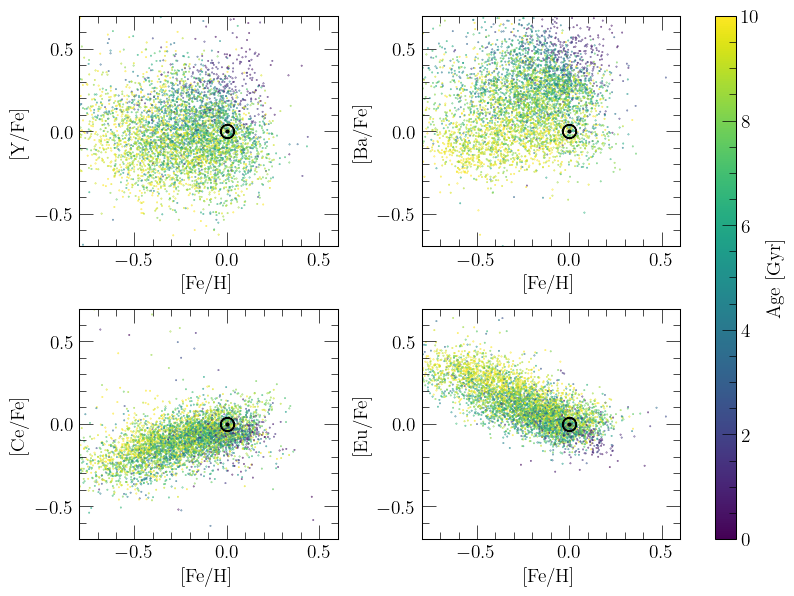

In [22]:
ELEMENTS = ["y", "ba", "ce", "eu"]
REFERENCE_ELEMENT = "fe"
COLORMAP = "viridis"

fig = plt.figure(figsize = (7, 6))
axes = []
for i in range(len(ELEMENTS)):
    axes.append(fig.add_subplot(221 + i))
    axes[i].set_xlabel("[%s/H]" % (REFERENCE_ELEMENT.capitalize()))
    axes[i].set_ylabel(r"[%s/%s]" % (ELEMENTS[i].capitalize(), REFERENCE_ELEMENT.capitalize()))
    axes[i].set_xlim([-0.8, 0.6])
    axes[i].set_ylim([-0.7, 0.7])

cbar_ax = fig.add_axes([0.9, 0.1, 0.1, 0.9])

stars = dr3giants.filter(
    "rgal", ">=", 7).filter(
    "rgal", "<=", 9).filter(
    "absz", "<=", 0.5)
for i in range(len(ELEMENTS)):
    sub = stars.filter("flag_%s_fe" % (ELEMENTS[i]), "==", 0)
    indices = np.random.choice(len(sub["star_id"]), size = 5000, replace = False)
    kwargs = {
        "c": [sub["age"][i] for i in indices],
        "cmap": plt.get_cmap(COLORMAP),
        "s": 0.1,
        "rasterized": True,
        "vmin": 0,
        "vmax": 10
    }
    if REFERENCE_ELEMENT == "fe":
        x = [sub["%s_h" % (REFERENCE_ELEMENT)][idx] for idx in indices]
        y = [sub["%s_%s" % (ELEMENTS[i], REFERENCE_ELEMENT)][idx] for idx in indices]
    else:
        x = [xfe + feh for xfe, feh in zip(sub["%s_fe" % (ELEMENTS[i])], sub["fe_h"])]
        x = [x[i] for i in indices]
        y = [xfe - mgfe for xfe, mgfe in zip(sub["%s_fe" % (ELEMENTS[i])], sub["mg_fe"])]
        y = [y[i] for i in indices]
    sc = axes[i].scatter(x, y, **kwargs)
    # axes[i].scatter(sub["%s_h" % (REFERENCE_ELEMENT)], sub["%s_%s" % (ELEMENTS[i], REFERENCE_ELEMENT)], **kwargs)

for ax in axes: ax.scatter([0], [0], marker = r"$\odot$", s = 100, color = named_colors()["black"])

cbar = plt.colorbar(sc, cax = cbar_ax, orientation = "vertical", location = "right")
cbar.set_label("Age [Gyr]")

plt.tight_layout()
cbar_ax.set_position([
    axes[-1].get_position().x1 + 0.05,
    axes[-1].get_position().y0,
    0.03,
    axes[0].get_position().y1 - axes[-1].get_position().y0
])
plt.show()